<a href="https://colab.research.google.com/github/amma-2004/Bid-Data-Project/blob/main/Big_Data_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Setup and Installation**

In [ ]:
!pip install pyspark

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

spark = SparkSession.builder.appName("CarPricePrediction").getOrCreate()

**2. Load Dataset**

In [ ]:
df = spark.read.csv('CAR DETAILS FROM CAR DEKHO.csv', header=True, inferSchema=True)

df.show(5)

print(f"Shape: ({df.count()}, {len(df.columns)})")
df.printSchema()

+--------------------+----+-------------+---------+------+-----------+------------+------------+
|                name|year|selling_price|km_driven|  fuel|seller_type|transmission|       owner|
+--------------------+----+-------------+---------+------+-----------+------------+------------+
|       Maruti 800 AC|2007|        60000|    70000|Petrol| Individual|      Manual| First Owner|
|Maruti Wagon R LX...|2007|       135000|    50000|Petrol| Individual|      Manual| First Owner|
|Hyundai Verna 1.6 SX|2012|       600000|   100000|Diesel| Individual|      Manual| First Owner|
|Datsun RediGO T O...|2017|       250000|    46000|Petrol| Individual|      Manual| First Owner|
|Honda Amaze VX i-...|2014|       450000|   141000|Diesel| Individual|      Manual|Second Owner|
+--------------------+----+-------------+---------+------+-----------+------------+------------+
only showing top 5 rows
Shape: (4340, 8)
root
 |-- name: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- sel

In [22]:
df.describe()

DataFrame[summary: string, name: string, year: string, selling_price: string, km_driven: string, fuel: string, seller_type: string, transmission: string, owner: string, name_index: string, fuel_index: string, seller_type_index: string, transmission_index: string, owner_index: string]

**3. Data Cleaning**

In [ ]:
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()

df = df.dropDuplicates()

print(f"New Shape: ({df.count()}, {len(df.columns)})")

+----+----+-------------+---------+----+-----------+------------+-----+
|name|year|selling_price|km_driven|fuel|seller_type|transmission|owner|
+----+----+-------------+---------+----+-----------+------------+-----+
|   0|   0|            0|        0|   0|          0|           0|    0|
+----+----+-------------+---------+----+-----------+------------+-----+

New Shape: (3577, 8)


**4. Exploratory Data Analysis (EDA)**

In [ ]:
df.describe(['selling_price', 'year', 'km_driven']).show()

df.groupBy('fuel').avg('selling_price').show()

df.groupBy('transmission').avg('selling_price').show()

+-------+------------------+------------------+-----------------+
|summary|     selling_price|              year|        km_driven|
+-------+------------------+------------------+-----------------+
|  count|              3577|              3577|             3577|
|   mean|473912.54207436397|2012.9625384400335|69250.54570869444|
| stddev|509301.80981603905| 4.251759082954623|47579.94001643144|
|    min|             20000|              1992|                1|
|    max|           8900000|              2020|           806599|
+-------+------------------+------------------+-----------------+

+--------+------------------+
|    fuel|avg(selling_price)|
+--------+------------------+
|  Diesel|        614001.075|
|     CNG|273162.08108108107|
|Electric|          310000.0|
|     LPG|171818.13636363635|
|  Petrol|335344.34012813045|
+--------+------------------+

+------------+------------------+
|transmission|avg(selling_price)|
+------------+------------------+
|   Automatic|1274955.1057692308

**5. Data Visualization**

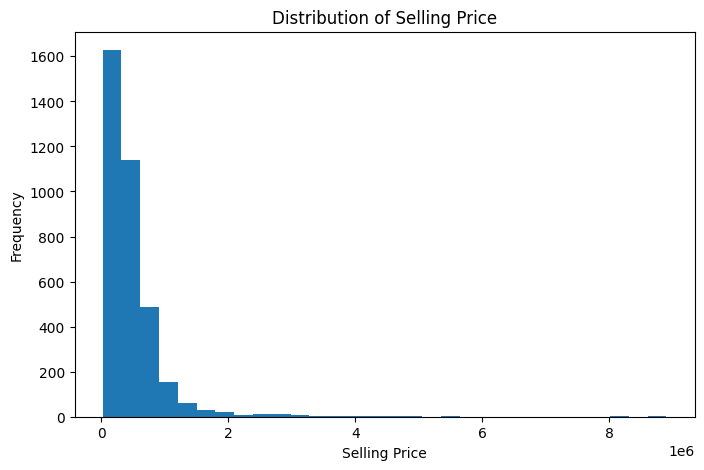

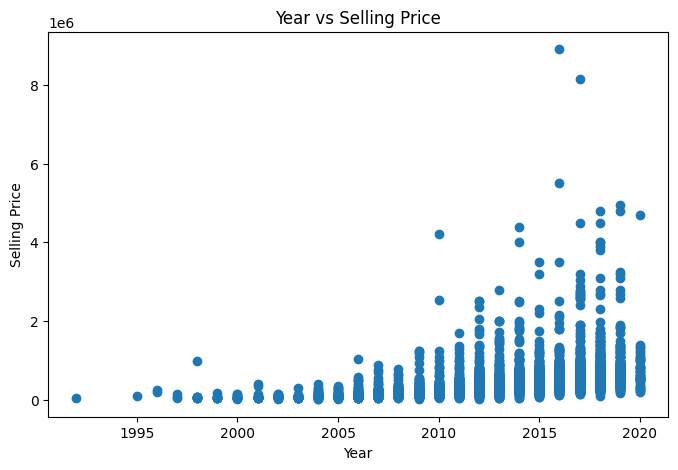

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

pdf = df.select('selling_price', 'year', 'km_driven').toPandas()

plt.figure(figsize=(8,5))
plt.hist(pdf['selling_price'], bins=30)
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Selling Price')
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(pdf['year'], pdf['selling_price'])
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.title('Year vs Selling Price')
plt.show()

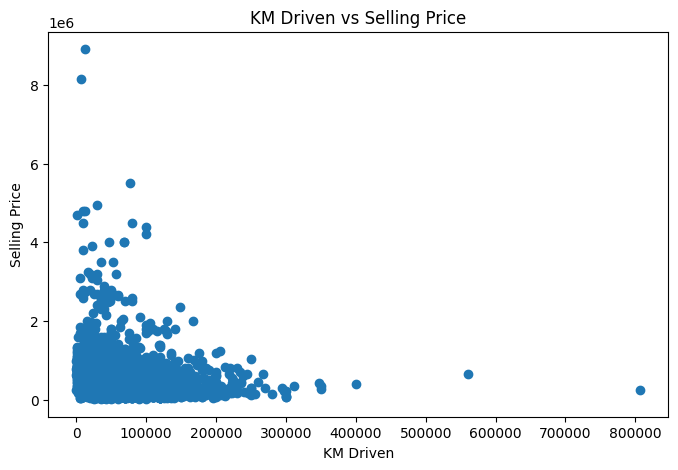

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(pdf['km_driven'], pdf['selling_price'])
plt.xlabel('KM Driven')
plt.ylabel('Selling Price')
plt.title('KM Driven vs Selling Price')
plt.show()

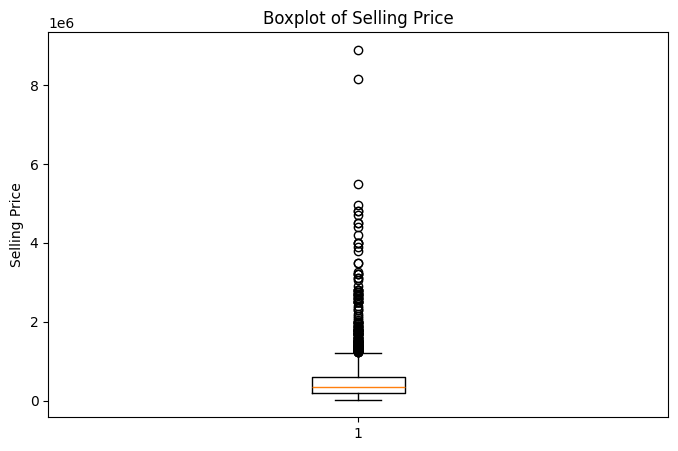

In [19]:
plt.figure(figsize=(8,5))
plt.boxplot(pdf['selling_price'])
plt.title('Boxplot of Selling Price')
plt.ylabel('Selling Price')
plt.show()

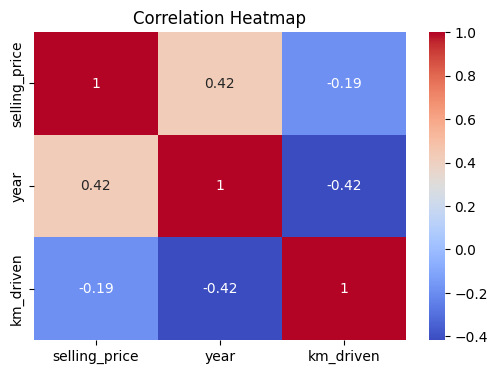

In [20]:
import seaborn as sns

corr = pdf.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

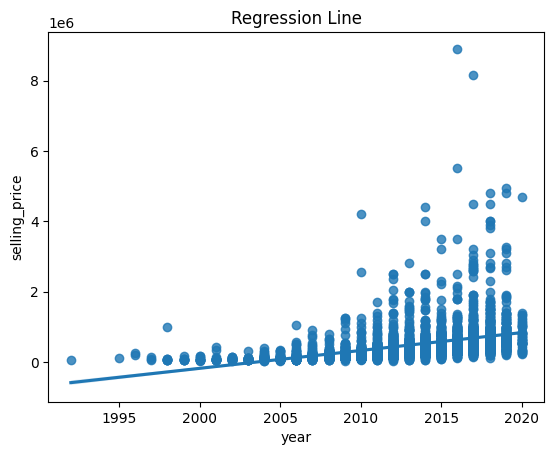

In [21]:
sns.regplot(x='year', y='selling_price', data=pdf)
plt.title('Regression Line')
plt.show()

**6. Data Preprocessing**

In [ ]:
categorical_columns = ['name', 'fuel', 'seller_type', 'transmission', 'owner']
indexers = [StringIndexer(inputCol=col, outputCol=col+"_index").fit(df) for col in categorical_columns]

for indexer in indexers:
    df = indexer.transform(df)

feature_cols = ['year', 'km_driven', 'name_index', 'fuel_index', 'seller_type_index', 'transmission_index', 'owner_index']

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
output = assembler.transform(df)

final_data = output.select("features", "selling_price")
final_data.show(5)

+--------------------+-------------+
|            features|selling_price|
+--------------------+-------------+
|[2014.0,40000.0,4...|       190000|
|[2010.0,120000.0,...|       100000|
|[2018.0,17500.0,4...|       540000|
|[2013.0,35299.0,4...|       325000|
|[2006.0,70000.0,1...|        80000|
+--------------------+-------------+
only showing top 5 rows


**7. Train/Test Split**

In [23]:
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

print(f"Train Count: {train_data.count()}")
print(f"Test Count: {test_data.count()}")

Train Count: 2915
Test Count: 662


**8. Machine Learning Model**

In [24]:
lr = LinearRegression(featuresCol="features", labelCol="selling_price")
model = lr.fit(train_data)

predictions = model.transform(test_data)
predictions.select("selling_price", "prediction").show(10)

+-------------+------------------+
|selling_price|        prediction|
+-------------+------------------+
|       254999|  546014.973459661|
|       300000| 490144.1455062628|
|       480000| 570497.8340875804|
|       535000| 551874.2247697711|
|       600000| 638087.1646611989|
|       750000| 699817.2439247221|
|       650000| 727404.0394389331|
|        70000| 188626.5896963328|
|       229999| 89162.63713490963|
|       100000|314198.83894364536|
+-------------+------------------+
only showing top 10 rows


**9. Model Evaluation**

In [ ]:
evaluator = RegressionEvaluator(labelCol="selling_price", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)

evaluator_r2 = RegressionEvaluator(labelCol="selling_price", predictionCol="prediction", metricName="r2")
r2 = evaluator_r2.evaluate(predictions)

mae = evaluator.setMetricName("mae").evaluate(predictions)

print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")
print(f"MAE: {mae}")

RMSE: 321109.79720862885
R2 Score: 0.46263217200821805
MAE: 197132.21786171102
